# Test technique NLP — Classification de commentaires citoyens sur les services publics
**Candidat :** BAKONDI Bahim · **Contexte :** sélection TAISS 2026 pour un stage chez Afriklang (Togo AI Lab)

**Objectif :** classer 150 commentaires citoyens (français, avec quelques insertions éwé/mina) en trois catégories : `Satisfaction`, `Insatisfaction`, `Suggestion`.

**Plan du notebook**
1. Exploration des données
2. Nettoyage du texte (dont mots éwé/mina) et stopwords
3. Visualisations (nuages de mots, termes fréquents)
4. Modélisation : vectorisation, entraînement, évaluation, analyse des erreurs
5. Conclusion : limites et pistes d'amélioration

In [1]:
import re
import unicodedata
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix, f1_score)
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_predict, cross_val_score,
                                     train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from wordcloud import WordCloud

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42  # graine unique pour toute l'expérience (reproductibilité)
CLASSES = ["Insatisfaction", "Satisfaction", "Suggestion"]
COULEURS = {"Insatisfaction": "#c0392b", "Satisfaction": "#27ae60", "Suggestion": "#2980b9"}

## 1. Chargement et exploration des données

### 1.1 Structure du dataset

In [2]:
df = pd.read_csv("../data/dataset_nlp_test_tal.csv")

print("Dimensions (lignes, colonnes) :", df.shape)
print("\nTypes des colonnes :")
print(df.dtypes)
print("\nValeurs manquantes :", df.isna().sum().to_dict())
print("Textes dupliqués   :", df["texte"].duplicated().sum())
df.head()

Dimensions (lignes, colonnes) : (150, 3)

Types des colonnes :
id           int64
texte          str
categorie      str
dtype: object

Valeurs manquantes : {'id': 0, 'texte': 0, 'categorie': 0}
Textes dupliqués   : 0


,id,texte,categorie
0,1,Manque total de communication entre les services.,Insatisfaction
1,2,Il serait bien de proposer des tutoriels vidéo...,Suggestion
2,3,Envoyer des SMS de confirmation lors de chaque...,Suggestion
3,4,Prévoir des interprètes pour les citoyens ne p...,Suggestion
4,5,Le formulaire en ligne plante au moment de la ...,Insatisfaction


### Exemples par catégorie

In [3]:
pd.set_option("display.max_colwidth", 120)
for categorie in CLASSES:
    print(f"\n=== {categorie} ===")
    print(df[df["categorie"] == categorie]["texte"].sample(4, random_state=SEED).to_string(index=False))


=== Insatisfaction ===
       Les informations données par téléphone étaient erronées.
On m'a demandé des pièces non mentionnées sur le site officiel.
Service fermé sans préavis le jour de mon rendez-vous confirmé.
   Le guichet était fermé sans aucune explication ni affichage.

=== Satisfaction ===
        Tout s'est bien passé, merci pour votre professionnalisme.
                Le bureau est bien situé et facilement accessible.
Processus transparent, j'ai pu suivre l'avancement de mon dossier.
       J'ai reçu mon document dans les délais, service impeccable.

=== Suggestion ===
Mettre en réseau les différentes mairies pour un meilleur partage des données.
   Prévoir une ligne téléphonique distincte pour les urgences administratives.
        Mettre à jour régulièrement le site web avec les nouvelles procédures.
         Afficher clairement les délais de traitement à l'entrée des services.


### 1.2 Distribution des classes et longueur des textes

categorie
Insatisfaction    50
Suggestion        50
Satisfaction      50
Name: count, dtype: int64

Longueur moyenne des textes par catégorie :


,nb_caracteres,nb_mots
categorie,,
Insatisfaction,57.8,9.3
Satisfaction,57.4,8.7
Suggestion,69.8,10.5


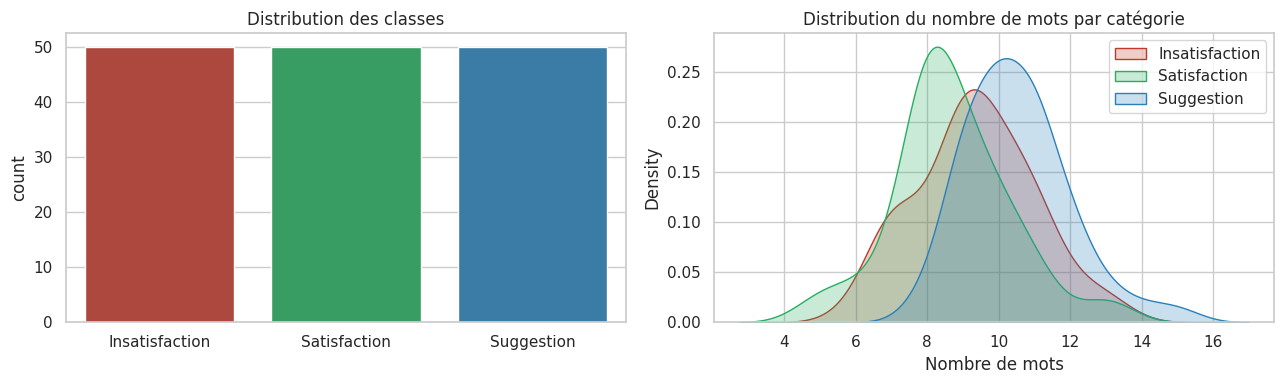

In [4]:
df["nb_caracteres"] = df["texte"].str.len()
df["nb_mots"] = df["texte"].str.split().str.len()

print(df["categorie"].value_counts())
print("\nLongueur moyenne des textes par catégorie :")
display(df.groupby("categorie")[["nb_caracteres", "nb_mots"]].mean().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=df, x="categorie", order=CLASSES, palette=COULEURS, ax=axes[0])
axes[0].set_title("Distribution des classes")
axes[0].set_xlabel("")
for categorie in CLASSES:
    sns.kdeplot(df.loc[df["categorie"] == categorie, "nb_mots"], label=categorie,
                color=COULEURS[categorie], fill=True, alpha=0.25, ax=axes[1])
axes[1].set_title("Distribution du nombre de mots par catégorie")
axes[1].set_xlabel("Nombre de mots")
axes[1].legend()
plt.tight_layout()
plt.show()

**Lecture :** les trois classes sont parfaitement équilibrées (50 textes chacune) : l'accuracy est donc une métrique honnête ici, et le F1 macro équivaut quasiment à elle. Les textes sont très courts (une dizaine de mots), ce qui limite le signal disponible pour chaque exemple. Seule différence de forme notable : les *Suggestions* sont un peu plus longues (≈ 70 caractères contre ≈ 58 pour les deux autres classes).

## 2. Nettoyage du texte

### 2.1 Mots éwé / mina : stratégie

Un repérage manuel du vocabulaire montre que seules **3 phrases** contiennent des mots éwé/mina (ex. « Akpe na wò, service très professionnel… »). Stratégie retenue :

1. **Repérer** ces textes avec un petit lexique et créer un indicateur `contient_ewe_mina`, pour mesurer leur poids dans le dataset.
2. **Traduire** uniquement les mots dont le sens est sûr (`akpe` → *merci*, `nyuie` → *bien*) : ce sont des marqueurs de satisfaction qu'un modèle entraîné sur du français ne verrait pas autrement.
3. **Conserver tels quels** les autres tokens éwé/mina (ne pas les supprimer comme du bruit) : un modèle à base de n-grammes de caractères peut tout de même en tirer parti. Leur glossaire est à compléter avec un locuteur natif.

In [5]:
# Glossaire de traduction (sens sûrs uniquement) et lexique de repérage
GLOSSAIRE_EWE_MINA = {"akpe": "merci", "nyuie": "bien"}
LEXIQUE_EWE_MINA = {"akpe", "nyuie", "hafi", "yèvu", "mele", "mègbe", "wò"}

def contient_ewe_mina(texte: str) -> bool:
    """Vrai si le texte contient au moins un mot du lexique éwé/mina."""
    mots = re.findall(r"[^\W\d_]+", texte.lower())
    return any(mot in LEXIQUE_EWE_MINA for mot in mots)

df["contient_ewe_mina"] = df["texte"].map(contient_ewe_mina)
print(f"{df['contient_ewe_mina'].sum()} textes mixtes français/éwé-mina sur {len(df)}")
df.loc[df["contient_ewe_mina"], ["id", "texte", "categorie"]]

3 textes mixtes français/éwé-mina sur 150


,id,texte,categorie
72,73,Yèvu service la nyuie hafi!,Satisfaction
130,131,"Mele via o, service la mègbe trop!",Insatisfaction
138,139,"Akpe na wò, service très professionnel et efficace.",Satisfaction


### 2.2 Stopwords français : choix de la liste

J'utilise une **liste maison** plutôt qu'une liste générique (NLTK, spaCy) pour deux raisons : elle n'ajoute aucune dépendance ni téléchargement, et surtout je la contrôle. Elle contient les mots-outils (articles, prépositions, pronoms, auxiliaires, conjonctions) mais **conserve volontairement** :

- les **négations** (`ne`, `pas`, `non`, `ni`, `jamais`, `aucun`, `aucune`, `sans`, `rien`), qui inversent le sens d'un avis ;
- les **intensificateurs** (`très`, `trop`, `plus`, `moins`, `peu`, `bien`, `mieux`), souvent porteurs de polarité ;
- les **verbes de modalité** (`faudrait`, `serait`, `pourraient`), typiques des suggestions.

Les listes génériques suppriment souvent ces mots et dégradent la détection de polarité.

In [6]:
STOPWORDS_BRUTS = """
le la les l un une des du de d au aux ce cet cette ces c ça cela ceci celui celle ceux celles
à a en et ou où que qu qui quoi dont par pour sur sous dans avec chez entre vers lors pendant depuis
il elle ils elles on je j tu nous vous me m te t se s moi toi lui eux leur leurs
mon ma mes ton ta tes son sa ses notre nos votre vos y
est sont suis es être étaient était été fut ai as avons avez ont avoir eu
mais donc car si comme alors aussi ainsi tout tous toute toutes même autre autres quelque quelques
plusieurs chaque quand dès via
""".split()

def retirer_accents(mot: str) -> str:
    """Supprime les accents (é -> e) : les citoyens écrivent souvent sans accents."""
    decompose = unicodedata.normalize("NFKD", mot)
    return "".join(c for c in decompose if not unicodedata.combining(c))

STOPWORDS = {retirer_accents(m) for m in STOPWORDS_BRUTS}
print(f"{len(STOPWORDS)} stopwords. Négations conservées :",
      [m for m in ["ne", "pas", "non", "ni", "jamais", "aucun", "aucune", "sans", "rien"] if m not in STOPWORDS])

118 stopwords. Négations conservées : ['ne', 'pas', 'non', 'ni', 'jamais', 'aucun', 'aucune', 'sans', 'rien']


### 2.3 Fonction de nettoyage

Étapes : minuscules → apostrophes/tirets en espaces (`l'agent` → `l agent`) → suppression ponctuation, chiffres et caractères spéciaux → glossaire éwé/mina → suppression des accents → retrait des stopwords et des tokens d'une lettre.

In [7]:
def nettoyer_texte(texte: str, retirer_stopwords: bool = True) -> str:
    """Normalise un commentaire et renvoie les tokens utiles séparés par des espaces."""
    texte = texte.lower().replace("’", "'")
    texte = re.sub(r"['\-/]", " ", texte)
    tokens = re.findall(r"[^\W\d_]+", texte)                 # lettres uniquement
    tokens = [GLOSSAIRE_EWE_MINA.get(t, t) for t in tokens]    # traduction éwé/mina sûre
    tokens = [retirer_accents(t) for t in tokens]
    return " ".join(
        t for t in tokens
        if len(t) > 1 and not (retirer_stopwords and t in STOPWORDS)
    )

df["texte_nettoye"] = df["texte"].map(nettoyer_texte)
df["texte_sans_filtre"] = df["texte"].map(lambda t: nettoyer_texte(t, retirer_stopwords=False))
df["tokens"] = df["texte_nettoye"].str.split()

pd.set_option("display.max_colwidth", 90)
df[["texte", "texte_nettoye"]].sample(6, random_state=SEED)

,texte,texte_nettoye
73,"L'application mobile fonctionne parfaitement, je recommande.",application mobile fonctionne parfaitement recommande
18,On m'a remis un document avec des fautes dans mon nom.,remis document fautes nom
118,"Service rapide, courtois et efficace. Félicitations.",service rapide courtois efficace felicitations
78,Prévoir une hotline dédiée aux professionnels et entreprises.,prevoir hotline dediee professionnels entreprises
76,Créer une FAQ en ligne pour réduire les appels répétitifs.,creer faq ligne reduire appels repetitifs
31,Aucune prise en charge des personnes à mobilité réduite.,aucune prise charge personnes mobilite reduite


Vérification sur les trois textes mixtes français/éwé-mina :

In [8]:
df.loc[df["contient_ewe_mina"], ["texte", "texte_nettoye"]]

,texte,texte_nettoye
72,Yèvu service la nyuie hafi!,yevu service bien hafi
130,"Mele via o, service la mègbe trop!",mele service megbe trop
138,"Akpe na wò, service très professionnel et efficace.",merci na wo service tres professionnel efficace


## 3. Visualisations

### 3.1 Nuage de mots par catégorie

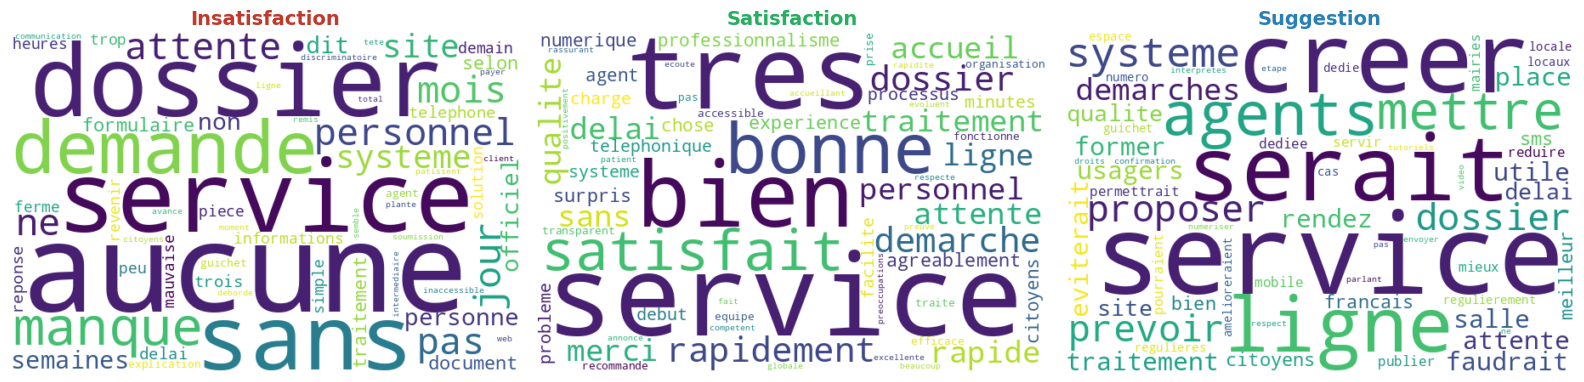

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, categorie in zip(axes, CLASSES):
    texte_classe = " ".join(df.loc[df["categorie"] == categorie, "texte_nettoye"])
    nuage = WordCloud(width=600, height=400, background_color="white", colormap="viridis",
                      max_words=60, random_state=SEED).generate(texte_classe)
    ax.imshow(nuage, interpolation="bilinear")
    ax.set_title(categorie, fontsize=14, color=COULEURS[categorie], fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.savefig("../results/wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Les 15 termes les plus fréquents par catégorie

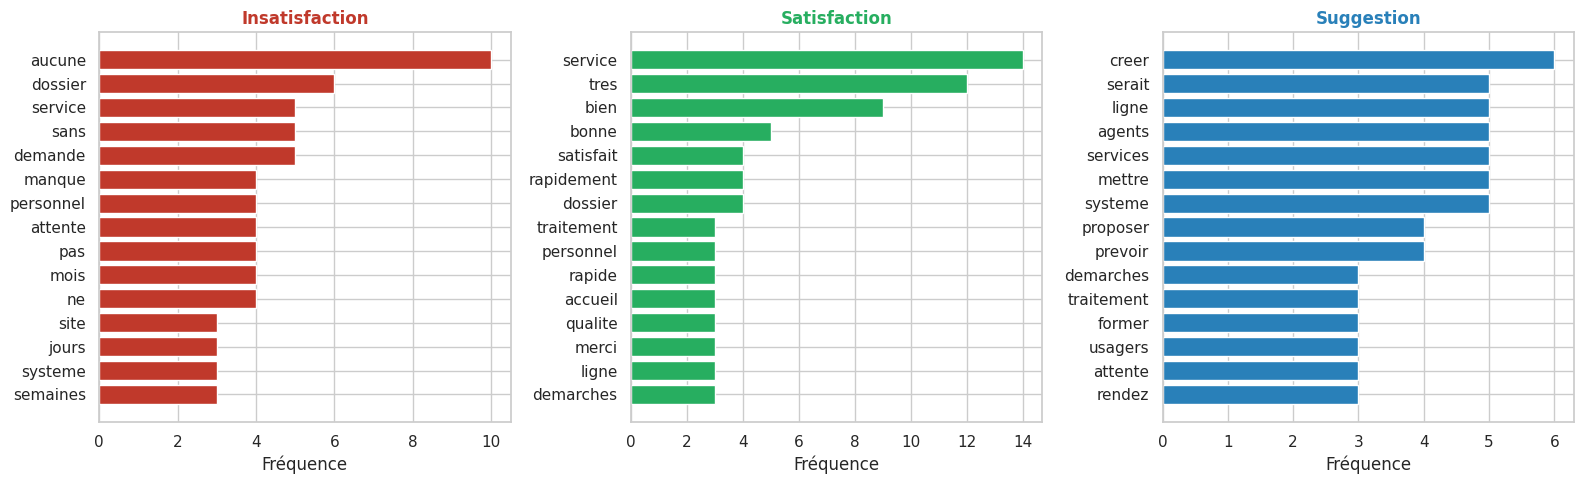

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, categorie in zip(axes, CLASSES):
    compteur = Counter(t for tokens in df.loc[df["categorie"] == categorie, "tokens"] for t in tokens)
    termes, frequences = zip(*compteur.most_common(15))
    ax.barh(termes[::-1], frequences[::-1], color=COULEURS[categorie])
    ax.set_title(categorie, color=COULEURS[categorie], fontweight="bold")
    ax.set_xlabel("Fréquence")
plt.tight_layout()
plt.savefig("../results/top_termes.png", dpi=150, bbox_inches="tight")
plt.show()

**Lecture :** chaque classe a quelques marqueurs nets. *Satisfaction* : `très`, `bien`, `bonne`, `satisfait`, `merci`. *Insatisfaction* : `aucune` (10 occurrences contre 1 en Satisfaction et 0 en Suggestion), `manque`, `sans`, `pas`, `ne`, `attente`. *Suggestion* : verbes d'action et de modalité (`créer`, `serait`, `mettre`, `prévoir`, `proposer`). En revanche, les mots du **sujet** (`service`, `dossier`, `traitement`, `personnel`, `ligne`, `système`) se retrouvent dans plusieurs classes : la catégorie dépend de l'**intention** (éloge, plainte, conseil) et non du thème, ce qui rend la tâche plus difficile pour un modèle à base de mots.

In [11]:
# Taille du vocabulaire et mots n'apparaissant qu'une seule fois (hapax)
frequences_globales = Counter(t for tokens in df["tokens"] for t in tokens)
nb_hapax = sum(1 for f in frequences_globales.values() if f == 1)
print(f"Vocabulaire après nettoyage : {len(frequences_globales)} mots distincts pour {len(df)} textes")
print(f"Mots vus une seule fois      : {nb_hapax} ({nb_hapax / len(frequences_globales):.0%})")

Vocabulaire après nettoyage : 494 mots distincts pour 150 textes
Mots vus une seule fois      : 346 (70%)


Une grande partie du vocabulaire n'apparaît qu'**une seule fois** : avec si peu de textes, la plupart des mots d'un nouveau commentaire n'ont jamais été vus à l'entraînement. C'est la principale difficulté du jeu de données, et l'argument en faveur de représentations qui généralisent mieux qu'un simple sac de mots (n-grammes de caractères ici, embeddings pré-entraînés en piste d'amélioration).

## 4. Modélisation

### 4.1 Vectorisation : choix justifié

Avec seulement 150 textes très courts, des embeddings entraînés sur ce corpus n'auraient aucun sens, et un modèle pré-entraîné multilingue relève du bonus. Je compare donc trois vectorisations « classiques » avec le même classifieur (régression logistique) en validation croisée stratifiée répétée (5 plis × 3 répétitions, F1 macro). Cette comparaison n'utilise pas le jeu de test de la section 4.2.

In [12]:
cv_comparaison = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

def score_cv(vectoriseur, colonne="texte_nettoye", classifieur=None):
    """F1 macro moyen (± écart-type) en CV répétée ; le vectoriseur est ré-ajusté à chaque pli."""
    classifieur = classifieur or LogisticRegression(max_iter=2000, C=10, random_state=SEED)
    scores = cross_val_score(make_pipeline(vectoriseur, classifieur),
                             df[colonne], df["categorie"], cv=cv_comparaison, scoring="f1_macro")
    return scores.mean(), scores.std()

vectoriseurs = {
    "CountVectorizer (mots)": CountVectorizer(),
    "TF-IDF mots (1-2 grammes)": TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True),
    "TF-IDF caractères (2-5 grammes)": TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True),
}
lignes = []
for nom, vec in vectoriseurs.items():
    moyenne, ecart = score_cv(vec)
    lignes.append({"Vectorisation": nom, "F1 macro (CV)": round(moyenne, 3), "± écart-type": round(ecart, 3)})
comparaison_vec = pd.DataFrame(lignes).set_index("Vectorisation")
comparaison_vec

,F1 macro (CV),± écart-type
Vectorisation,,
CountVectorizer (mots),0.687,0.103
TF-IDF mots (1-2 grammes),0.685,0.095
TF-IDF caractères (2-5 grammes),0.728,0.095


**Choix retenu : TF-IDF sur n-grammes de caractères (2 à 5).** C'est la meilleure option ici, pour trois raisons : (1) le TF-IDF pondère les mots rares et discriminants plutôt que les mots omniprésents ; (2) les n-grammes de caractères captent les variantes morphologiques (`faciliter`, `facilite`, `faciliterait`) et sont robustes aux fautes et aux accents manquants ; (3) ils s'appliquent aussi aux mots éwé/mina, qu'aucun dictionnaire français ne connaît. L'écart avec les mots seuls reste dans la marge d'incertitude (écart-type ≈ 0,09) : j'en tire une tendance, pas une certitude.

### Effet du retrait des stopwords (ablation)

In [13]:
vec_final = lambda: TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True)
ablation = pd.DataFrame({
    "Avec stopwords retirés (consigne)": score_cv(vec_final(), "texte_nettoye"),
    "Sans retrait des stopwords": score_cv(vec_final(), "texte_sans_filtre"),
}, index=["F1 macro (CV)", "± écart-type"]).T.round(3)
ablation

,F1 macro (CV),± écart-type
Avec stopwords retirés (consigne),0.728,0.095
Sans retrait des stopwords,0.746,0.089


Le retrait des stopwords ne **améliore pas** le score ici : il le baisse d'environ 0,02, un écart bien inférieur à l'écart-type (≈ 0,09), donc non significatif. Hypothèse (non démontrée) : sur des phrases de dix mots, certains mots-outils (formes verbales, `a été`, pronoms) portent déjà un peu de signal sur la polarité et le mode. Je conserve néanmoins le retrait dans le pipeline principal, car il est demandé par le sujet, avec une liste prudente qui préserve les négations.

### 4.2 Découpage train / test (80 / 20)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    df["texte_nettoye"], df["categorie"],
    test_size=0.20, stratify=df["categorie"], random_state=SEED,
)
print(f"Train : {len(X_train)} textes | Test : {len(X_test)} textes")
print("Répartition train :", y_train.value_counts().to_dict())
print("Répartition test  :", y_test.value_counts().to_dict())

Train : 120 textes | Test : 30 textes
Répartition train : {'Insatisfaction': 40, 'Suggestion': 40, 'Satisfaction': 40}
Répartition test  : {'Insatisfaction': 10, 'Suggestion': 10, 'Satisfaction': 10}


Le découpage est **stratifié** (mêmes proportions de classes dans train et test) et la graine est fixée. Le nettoyage est sans état (aucune statistique apprise sur les données), donc l'appliquer avant le découpage ne provoque pas de fuite de données ; le vectoriseur, lui, est ajusté **uniquement sur le train**, grâce aux `Pipeline`.

### 4.3 Entraînement de quatre algorithmes

In [15]:
def nouveau_vectoriseur():
    return TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), sublinear_tf=True)

classifieurs = {
    "Régression logistique": LogisticRegression(max_iter=2000, C=10, random_state=SEED),
    "SVM linéaire": LinearSVC(C=1.0, random_state=SEED),
    "Naive Bayes multinomial": MultinomialNB(alpha=0.5),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
}
pipelines = {nom: make_pipeline(nouveau_vectoriseur(), clf) for nom, clf in classifieurs.items()}

for nom, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
print("Modèles entraînés :", list(pipelines))

Modèles entraînés : ['Régression logistique', 'SVM linéaire', 'Naive Bayes multinomial', 'Random Forest']


### 4.4 Évaluation

In [16]:
cv_stable = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
resultats, predictions = [], {}

for nom, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    predictions[nom] = y_pred
    cv_scores = cross_val_score(make_pipeline(nouveau_vectoriseur(), classifieurs[nom]),
                                df["texte_nettoye"], df["categorie"], cv=cv_stable, scoring="f1_macro")
    resultats.append({
        "Modèle": nom,
        "Accuracy (test)": accuracy_score(y_test, y_pred),
        "F1 macro (test)": f1_score(y_test, y_pred, average="macro"),
        "F1 macro (CV 5x3)": cv_scores.mean(),
        "± CV": cv_scores.std(),
    })

synthese = pd.DataFrame(resultats).set_index("Modèle").round(3).sort_values("F1 macro (CV 5x3)", ascending=False)
synthese.to_csv("../results/synthese_modeles.csv")
synthese

,Accuracy (test),F1 macro (test),F1 macro (CV 5x3),± CV
Modèle,,,,
Régression logistique,0.833,0.833,0.728,0.095
SVM linéaire,0.833,0.833,0.716,0.101
Random Forest,0.833,0.833,0.679,0.086
Naive Bayes multinomial,0.833,0.833,0.676,0.082


**Comment lire ce tableau.** Le jeu de test ne compte que **30 textes** : un seul texte de plus ou de moins déplace l'accuracy de 3,3 points. Les scores « test » sont donc très bruités. La colonne **CV 5×3** (15 évaluations sur les 150 textes) est plus fiable pour **classer** les modèles ; le test 80/20 sert à produire les matrices de confusion demandées.

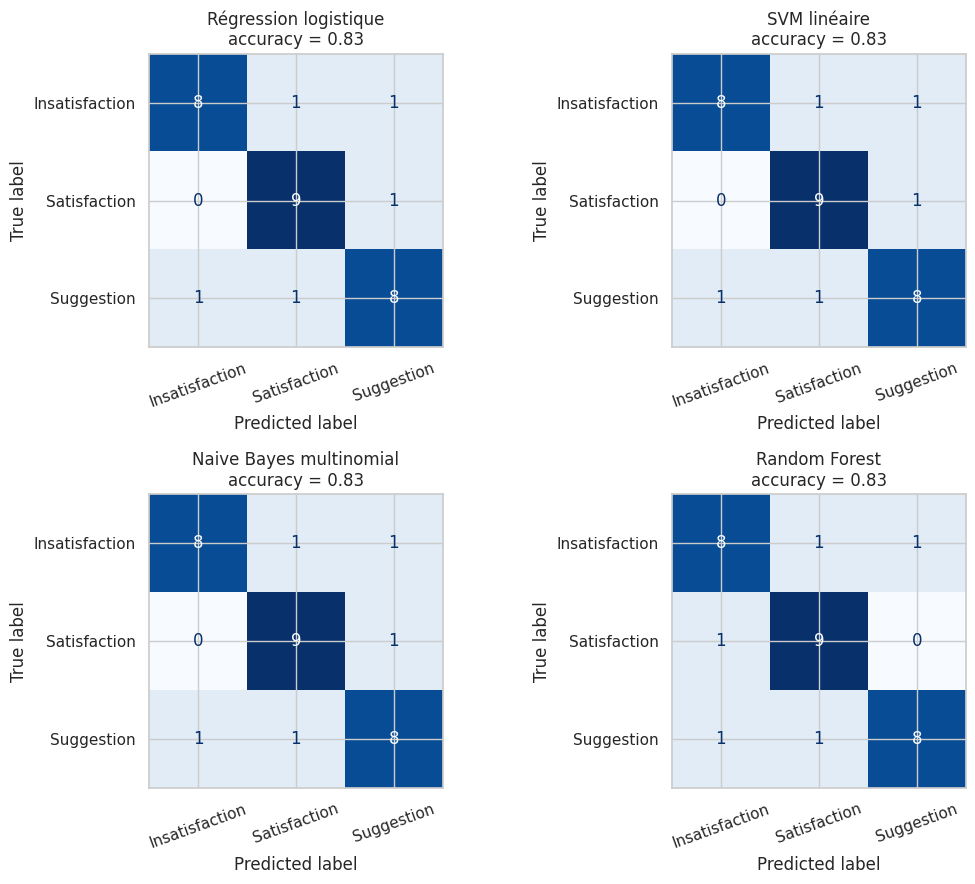

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, (nom, y_pred) in zip(axes.ravel(), predictions.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred, labels=CLASSES), display_labels=CLASSES
                           ).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=20)
    ax.set_title(f"{nom}\naccuracy = {accuracy_score(y_test, y_pred):.2f}")
plt.tight_layout()
plt.savefig("../results/matrices_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
meilleur_nom = synthese.index[0]
print(f"Meilleur modèle (F1 macro en CV) : {meilleur_nom}\n")
print(classification_report(y_test, predictions[meilleur_nom], labels=CLASSES, zero_division=0))
pd.DataFrame(confusion_matrix(y_test, predictions[meilleur_nom], labels=CLASSES),
             index=[f"vrai : {c}" for c in CLASSES], columns=[f"prédit : {c}" for c in CLASSES])

Meilleur modèle (F1 macro en CV) : Régression logistique

                precision    recall  f1-score   support

Insatisfaction       0.89      0.80      0.84        10
  Satisfaction       0.82      0.90      0.86        10
    Suggestion       0.80      0.80      0.80        10

      accuracy                           0.83        30
     macro avg       0.84      0.83      0.83        30
  weighted avg       0.84      0.83      0.83        30



,prédit : Insatisfaction,prédit : Satisfaction,prédit : Suggestion
vrai : Insatisfaction,8,1,1
vrai : Satisfaction,0,9,1
vrai : Suggestion,1,1,8


**Interprétation**

- **Les quatre modèles obtiennent la même accuracy sur le test** (0,83, soit 25 textes sur 30) : cet échantillon est trop petit pour les départager.
- **En validation croisée**, les modèles linéaires (régression logistique ≈ 0,73 ; SVM ≈ 0,72) sont légèrement devant Random Forest et Naive Bayes (≈ 0,68), mais les écarts restent inférieurs à un écart-type (≈ 0,09) : je n'affirme pas de supériorité nette. Les modèles linéaires restent un choix naturel pour des vecteurs creux de grande dimension avec peu d'exemples.
- **Matrice de confusion (régression logistique, test)** : 8 Insatisfactions, 9 Satisfactions et 8 Suggestions sur 10 sont bien classées. Les 5 erreurs sont isolées (une par type de confusion, pour cinq des six types possibles) : à cette échelle, aucune confusion ne domine.
- **Estimation à retenir** : l'écart entre le test 80/20 (0,83) et la CV (≈ 0,73) montre que le découpage du test est plutôt favorable. La CV, qui utilise les 150 textes, donne l'estimation la plus fiable de la performance réelle.

### 4.5 Analyse des erreurs

Sur 30 textes de test, le nombre d'erreurs est faible et peu représentatif. Pour analyser les erreurs sur un échantillon plus large, j'utilise les **prédictions « out-of-fold »** du meilleur modèle : chaque texte des 150 est prédit par un modèle qui ne l'a jamais vu à l'entraînement.

In [19]:
cv_erreurs = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
modele_final = make_pipeline(nouveau_vectoriseur(), classifieurs[meilleur_nom])
df["prediction_oof"] = cross_val_predict(modele_final, df["texte_nettoye"], df["categorie"], cv=cv_erreurs)
erreurs = df[df["prediction_oof"] != df["categorie"]]

print(f"{len(erreurs)} erreurs sur {len(df)} textes ({len(erreurs)/len(df):.0%}) avec {meilleur_nom}")
print("\nConfusions les plus fréquentes (vrai -> prédit) :")
print(erreurs.groupby(["categorie", "prediction_oof"]).size().sort_values(ascending=False).to_string())
print("\nRapport sur les 150 prédictions out-of-fold :")
print(classification_report(df["categorie"], df["prediction_oof"]))

42 erreurs sur 150 textes (28%) avec Régression logistique

Confusions les plus fréquentes (vrai -> prédit) :
categorie       prediction_oof
Satisfaction    Insatisfaction    11
Insatisfaction  Satisfaction      10
                Suggestion         8
Suggestion      Insatisfaction     6
Satisfaction    Suggestion         4
Suggestion      Satisfaction       3

Rapport sur les 150 prédictions out-of-fold :
                precision    recall  f1-score   support

Insatisfaction       0.65      0.64      0.65        50
  Satisfaction       0.73      0.70      0.71        50
    Suggestion       0.77      0.82      0.80        50

      accuracy                           0.72       150
     macro avg       0.72      0.72      0.72       150
  weighted avg       0.72      0.72      0.72       150



In [20]:
pd.set_option("display.max_colwidth", 100)
erreurs.sample(5, random_state=SEED)[["texte", "categorie", "prediction_oof"]].reset_index(drop=True)

,texte,categorie,prediction_oof
0,"Service de première classe, je n'ai aucune remarque négative.",Satisfaction,Insatisfaction
1,Allonger les horaires d'ouverture pour inclure les samedis matin.,Suggestion,Insatisfaction
2,"Le délai annoncé a été respecté, c'est rassurant.",Satisfaction,Insatisfaction
3,La clarté des informations fournies facilite les démarches.,Satisfaction,Insatisfaction
4,Le personnel fait preuve de beaucoup de professionnalisme.,Satisfaction,Insatisfaction


**Bilan des erreurs (150 prédictions out-of-fold)**

- La classe **Suggestion** est la mieux reconnue (rappel ≈ 0,82) : ses marqueurs (`serait`, `mettre`, `prévoir`, `créer`) sont nets. **Insatisfaction** est la plus difficile (rappel ≈ 0,64).
- La confusion dominante est une **inversion de polarité** : 21 des 42 erreurs opposent Satisfaction et Insatisfaction (11 + 10).

**Analyse des 5 exemples affichés** (hypothèses appuyées sur les fréquences du dataset)

1. *« Service de première classe, je n'ai aucune remarque négative. »* (Satisfaction → Insatisfaction) : `aucune` apparaît 10 fois en Insatisfaction, 1 fois en Satisfaction (ce texte) et jamais en Suggestion. La double négation (« aucune remarque négative » = positif) est invisible pour un sac de n-grammes, qui ne voit que le mot « aucune » et « négative ».
2. *« Allonger les horaires d'ouverture pour inclure les samedis matin. »* (Suggestion → Insatisfaction) : aucun marqueur habituel de suggestion (`serait`, `mettre`, `prévoir`, `créer`) ; le verbe à l'infinitif `allonger` est rare, et `horaires` / `ouverture` n'apparaissent ailleurs que dans une plainte du jeu de données.
3. *« Le délai annoncé a été respecté, c'est rassurant. »* (Satisfaction → Insatisfaction) : une plainte du jeu (« Le délai de 7 jours annoncé s'est transformé en 2 mois ») partage les mots `délai` et `annoncé`. Le sens positif repose sur `respecté` et `rassurant`, trop rares pour peser.
4. *« La clarté des informations fournies facilite les démarches. »* (Satisfaction → Insatisfaction) : `informations` apparaît surtout dans des plaintes (« informations erronées », « informations obsolètes ») et le texte ne contient aucun marqueur positif fréquent comme `très` ou `bien`.
5. *« Le personnel fait preuve de beaucoup de professionnalisme. »* (Satisfaction → Insatisfaction) : `professionnalisme` n'apparaît que 2 fois dans tout le jeu de données (il peut manquer dans le pli d'entraînement) et `personnel` n'est pas discriminant (présent autant dans les plaintes que dans les éloges).

**Causes récurrentes :** (a) négations et tournures composées non modélisées, (b) vocabulaire rare ou vu une seule fois, (c) absence des marqueurs fréquents de la classe, (d) mots du sujet partagés entre classes. Les erreurs exactes peuvent varier légèrement selon la version de scikit-learn ; les causes restent les mêmes.

## 5. Conclusion

### Bilan
Le pipeline complet (nettoyage avec gestion éwé/mina → TF-IDF sur n-grammes de caractères → 4 classifieurs) atteint, avec la **régression logistique**, un F1 macro de **≈ 0,83 sur le test 80/20** (30 textes) et de **≈ 0,73 en validation croisée répétée** ; c'est cette seconde valeur qu'il faut retenir. La classe *Suggestion* est la mieux reconnue ; la principale confusion oppose *Satisfaction* et *Insatisfaction*.

### Limites
- **Très peu de données** : 150 textes, un vocabulaire dispersé (beaucoup de mots vus une seule fois) et un test de 30 textes, d'où des scores bruités (± 0,09 en CV) et des écarts entre modèles non significatifs.
- **Un sac de n-grammes ignore la syntaxe** : négations composées, ironie et ordre des mots (`aucune remarque négative`) sont mal gérés.
- **Éwé/mina** : seulement 3 textes concernés et un glossaire de 2 mots sûrs, à faire valider par un locuteur natif. Les tokens éwé/mina restent traités comme du bruit lexical.
- **Pas de réglage d'hyperparamètres** : choix volontaire pour ne pas sur-ajuster sur 150 exemples, mais cela laisse probablement quelques points de performance de côté.

### Pistes d'amélioration
1. **Embeddings / fine-tuning multilingue** (CamemBERT, XLM-R, LaBSE) : ils apportent une représentation sémantique pré-apprise, plus robuste aux mots rares et aux négations, et mieux adaptée à un corpus français mêlé de langues africaines. Une approche few-shot (SetFit) conviendrait à la taille du jeu.
2. **Plus de données et d'annotations** : collecter davantage de retours citoyens, augmenter les données (paraphrases, rétro-traduction) et constituer un petit corpus annoté éwé/mina avec un locuteur natif.
3. **Variables linguistiques ciblées** : détection des négations composées, du conditionnel et de l'infinitif en début de phrase (marqueurs de suggestion), à ajouter aux n-grammes.
4. **Validation plus rigoureuse** : CV imbriquée pour régler les hyperparamètres sans fuite, et intervalles de confiance sur les scores.
5. **Déploiement** : interface Streamlit/Gradio pour tester un nouveau commentaire.